## demo4: Perform group analysis on the data to filter the data in RTQC that contains the same patterns as the DMQC data

This demo illustrates how to:

1. Partition hydrographic data by month to account for seasonal variability.
2. Apply a K-means clustering approach to salinity values below a specified depth threshold.
3. Identify RTQC profiles that exhibit salinity patterns similar to DMQC profiles.
4. Assign a CLUSTER_QC flag based on clustering results.
5. Visualize monthly thermohaline distributions before and after filtering.

In [1]:
import pandas as pd
import cluster_qc

In [2]:
polygon = pd.read_csv("data/off_bcs.csv", usecols=['latitude','longitude'])

data = pd.read_csv("./data/profile_measurements.csv")
data["DATE"] = pd.to_datetime(data["DATE"], format="mixed")
data["YEAR"] = data["DATE"].dt.year
data["MONTH"] = data["DATE"].dt.month
data

,PLATFORM_NUMBER,CYCLE_NUMBER,DATA_MODE,DATE,LATITUDE,LONGITUDE,PRES,TEMP,PSAL,YEAR,MONTH
0,1902645,1,A,2024-05-23 07:01:06.000752640,20.897200,-111.494100,4.31,22.390,34.577,2024,5
1,1902645,1,A,2024-05-23 07:01:06.000752640,20.897200,-111.494100,6.11,22.388,34.577,2024,5
2,1902645,1,A,2024-05-23 07:01:06.000752640,20.897200,-111.494100,8.11,22.381,34.576,2024,5
3,1902645,1,A,2024-05-23 07:01:06.000752640,20.897200,-111.494100,10.11,22.375,34.576,2024,5
4,1902645,1,A,2024-05-23 07:01:06.000752640,20.897200,-111.494100,12.11,22.385,34.576,2024,5
...,...,...,...,...,...,...,...,...,...,...,...
1817306,4902475,184,R,2024-06-02 17:38:00.000000000,22.954834,-111.832855,1985.40,2.277,34.632,2024,6
1817307,4902475,184,R,2024-06-02 17:38:00.000000000,22.954834,-111.832855,1995.40,2.261,34.633,2024,6
1817308,4902475,184,R,2024-06-02 17:38:00.000000000,22.954834,-111.832855,2005.50,2.245,34.633,2024,6
1817309,4902475,184,R,2024-06-02 17:38:00.000000000,22.954834,-111.832855,2016.10,2.226,34.634,2024,6


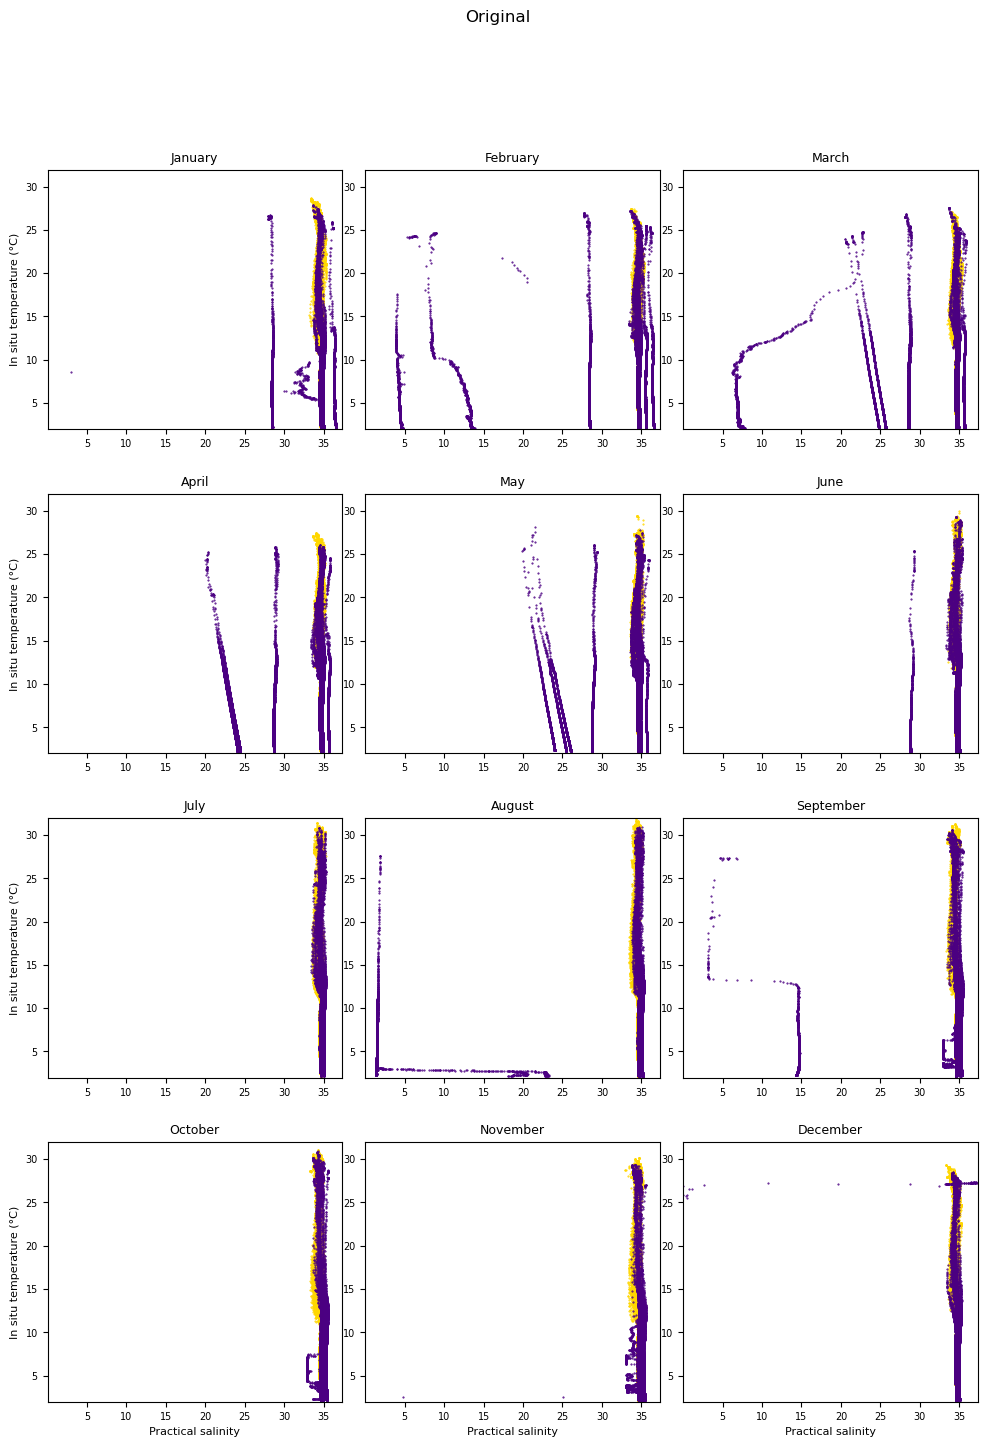

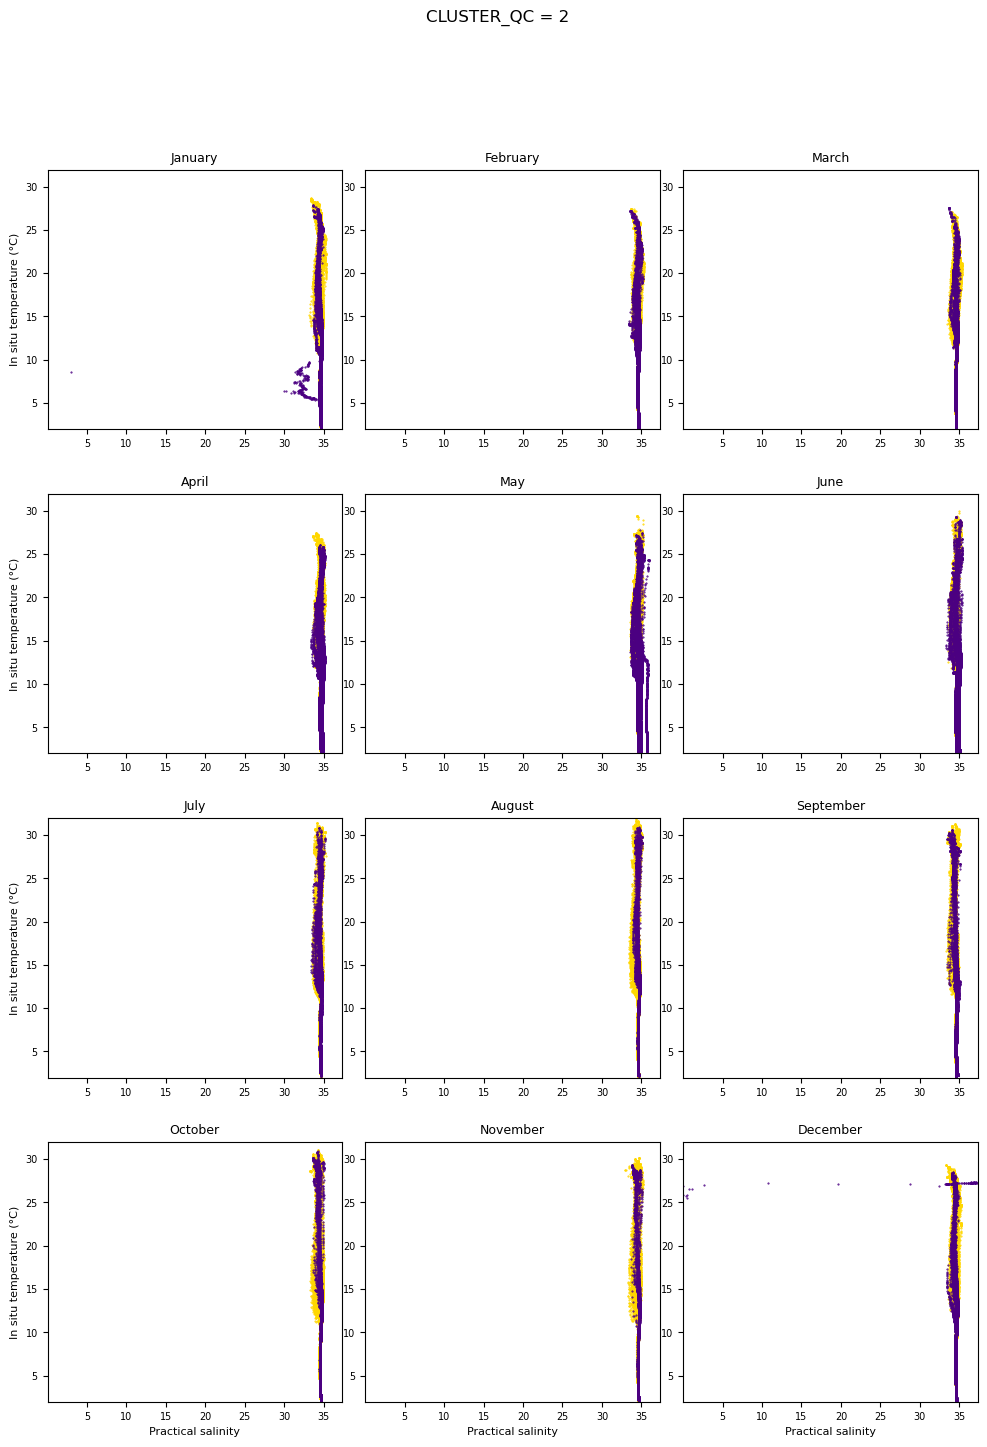

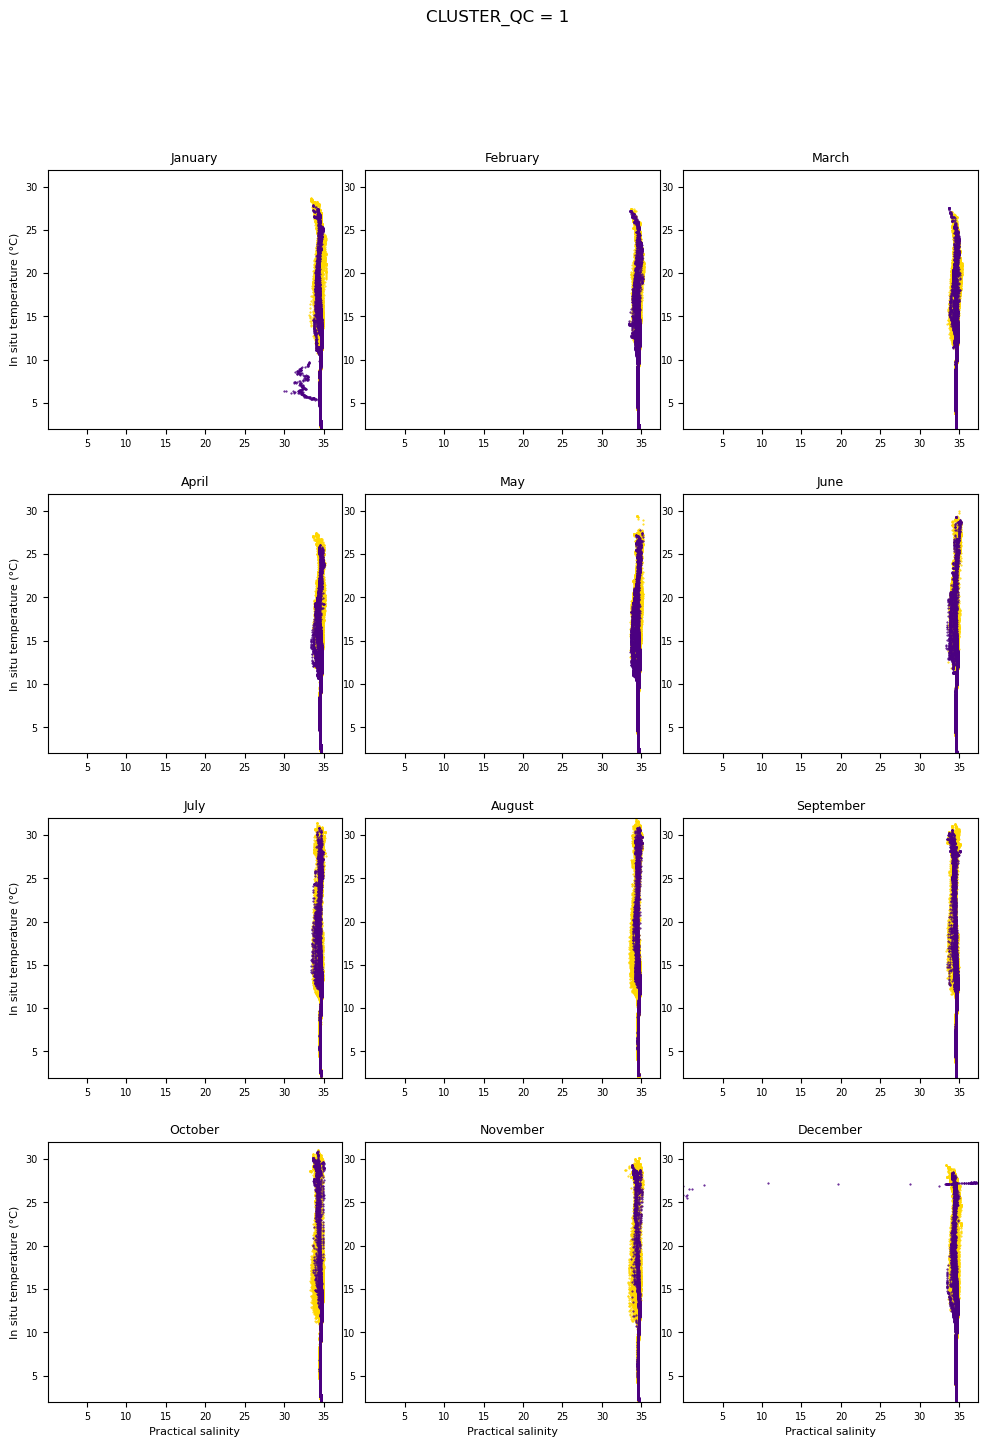

In [3]:
data_qc, figs = cluster_qc.cluster_analysis(data, storage_path="./data", depth=-1700)

In [4]:
data_qc.to_csv("./data/cluster_qc_measurements.csv", index=False)
data_qc

,PLATFORM_NUMBER,CYCLE_NUMBER,DATA_MODE,DATE,LATITUDE,LONGITUDE,PRES,TEMP,PSAL,YEAR,MONTH,Z,CLUSTER_QC
0,4902903,185,A,2022-01-09 05:25:00.000572672,18.943000,-109.723000,3.84,26.459,34.539997,2022,1,-3.816751,2
1,4902903,185,A,2022-01-09 05:25:00.000572672,18.943000,-109.723000,5.74,26.460,34.540997,2022,1,-5.705221,2
2,4902903,185,A,2022-01-09 05:25:00.000572672,18.943000,-109.723000,7.74,26.458,34.539997,2022,1,-7.693066,2
3,4902903,185,A,2022-01-09 05:25:00.000572672,18.943000,-109.723000,9.74,26.468,34.545000,2022,1,-9.680891,2
4,4902903,185,A,2022-01-09 05:25:00.000572672,18.943000,-109.723000,11.74,26.469,34.546997,2022,1,-11.668697,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1694854,4902475,24,D,2019-12-24 05:18:00.000000000,21.016411,-111.975029,1937.90,2.336,34.624012,2019,12,-1917.062662,1
1694855,4902475,24,D,2019-12-24 05:18:00.000000000,21.016411,-111.975029,1962.90,2.319,34.625000,2019,12,-1941.680060,1
1694856,4902475,24,D,2019-12-24 05:18:00.000000000,21.016411,-111.975029,1988.20,2.273,34.628000,2019,12,-1966.589977,1
1694857,4902475,24,D,2019-12-24 05:18:00.000000000,21.016411,-111.975029,2013.80,2.233,34.629997,2019,12,-1991.792310,1
